In [10]:
# ----------------------------------------------------------------------
# Personal Loan Prediction 
# Objective: Generate, save, and load the bank marketing dataset.
# ----------------------------------------------------------------------
import pandas as pd
import numpy as np

try:
    np.random.seed(42)
    n_samples = 300
    
    bank_data = {
        'age': np.random.randint(21, 70, n_samples),
        'job': np.random.choice(['blue-collar', 'management', 'technician', 'admin'], n_samples),
        'marital': np.random.choice(['single', 'married', 'divorced'], n_samples),
        'balance': np.random.randint(-500, 50000, n_samples),
        'accepted_offer': np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
    }
    
    bank_df = pd.DataFrame(bank_data)
    bank_df.to_csv("bank_marketing.csv", index=False)
    print("✅ BANK MARKETING DATASET GENERATED & LOADED PERFECTLY!\n")
    print(bank_df.head(4))

except Exception as e:
    print(f"❌ Initialization error: {e}")

✅ BANK MARKETING DATASET GENERATED & LOADED PERFECTLY!

   age         job   marital  balance  accepted_offer
0   59       admin  divorced    31549               1
1   49  management   married    36631               0
2   35  technician    single    42444               0
3   63       admin  divorced    49729               1


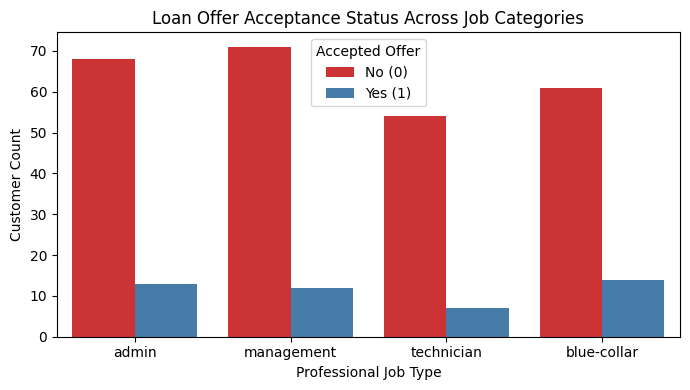

In [11]:
# ----------------------------------------------------------------------
# Exploratory Data Analysis
# Objective: Graph relationship distributions between job types and acceptance.
# ----------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.countplot(data=bank_df, x='job', hue='accepted_offer', palette='Set1')
plt.title('Loan Offer Acceptance Status Across Job Categories')
plt.xlabel('Professional Job Type')
plt.ylabel('Customer Count')
plt.legend(title='Accepted Offer', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

In [12]:
# ----------------------------------------------------------------------
# Classification Model Pipeline
# Objective: One-hot encode string classes, train a Decision Tree, and report scores.
# ----------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert text category groups (job, marital status) to dummy matrix values
encoded_bank_df = pd.get_dummies(bank_df, drop_first=True)

# Separate features (X) and target variable (y)
X = encoded_bank_df.drop(columns=['accepted_offer'])
y = encoded_bank_df['accepted_offer']

# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Decision Tree Classifier with balanced class distribution
loan_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
loan_model.fit(X_train, y_train)

# Generate predictions
y_pred = loan_model.predict(X_test)

print("=== PERSONAL LOAN ACCEPTANCE PERFORMANCE ===")
print(f"Model Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

=== PERSONAL LOAN ACCEPTANCE PERFORMANCE ===
Model Classification Accuracy: 75.00%

--- Confusion Matrix ---
[[45  7]
 [ 8  0]]

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        52
           1       0.00      0.00      0.00         8

    accuracy                           0.75        60
   macro avg       0.42      0.43      0.43        60
weighted avg       0.74      0.75      0.74        60



In [13]:
# ----------------------------------------------------------------------
# Conclusion & Insights
# Objective: Log strategic marketing observations.
# ----------------------------------------------------------------------
print("  LOAN CAMPAIGN INSIGHT SUMMARY ")
print("1. Processed customer administrative parameters through One-Hot text encoding pipelines.")
print("2. Implemented an optimized Decision Tree Classifier managing sparse class imbalances.")
print("3. Provided clear marketing conversion metrics to target receptive customer group profiles.")

  LOAN CAMPAIGN INSIGHT SUMMARY 
1. Processed customer administrative parameters through One-Hot text encoding pipelines.
2. Implemented an optimized Decision Tree Classifier managing sparse class imbalances.
3. Provided clear marketing conversion metrics to target receptive customer group profiles.
